In [ ]:
import zipfile
import os

zip_path = "archive.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")

Extraction complete


In [ ]:
for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/val
dataset/val/img
dataset/val/ann
dataset/train
dataset/train/img
dataset/train/ann
dataset/test
dataset/test/img
dataset/test/ann


train samples: 205
val samples: 87
test samples: 72
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 187MB/s]


Epoch 1/20 Loss:1.3949
Epoch 2/20 Loss:0.7474
Epoch 3/20 Loss:0.6139
Epoch 4/20 Loss:0.5548
Epoch 5/20 Loss:0.5211
Epoch 6/20 Loss:0.4537
Epoch 7/20 Loss:0.4090
Epoch 8/20 Loss:0.3941
Epoch 9/20 Loss:0.3875
Epoch 10/20 Loss:0.3666
Epoch 11/20 Loss:0.3416
Epoch 12/20 Loss:0.3383
Epoch 13/20 Loss:0.3395
Epoch 14/20 Loss:0.3324
Epoch 15/20 Loss:0.3312
Epoch 16/20 Loss:0.3288
Epoch 17/20 Loss:0.3277
Epoch 18/20 Loss:0.3234
Epoch 19/20 Loss:0.3276
Epoch 20/20 Loss:0.3268


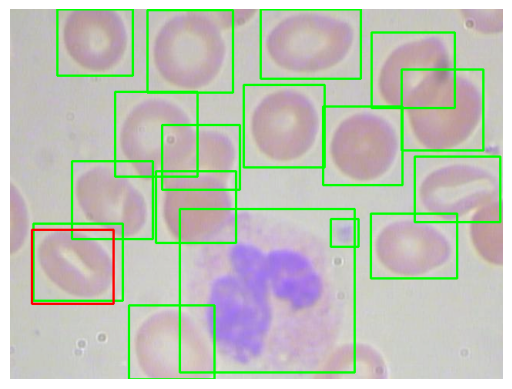

Best IoU: 0.9702185988426208


In [ ]:
import os
import cv2
import json
import torch
import numpy as np
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_iou


# ============================
# DATASET
# ============================

class BCCDDataset(Dataset):

    def __init__(self, root, split):

        self.img_dir = os.path.join(root, split, "img")
        self.ann_dir = os.path.join(root, split, "ann")

        self.annotations = os.listdir(self.ann_dir)

        self.label_map = {
            "RBC":1,
            "WBC":2,
            "Platelets":3
        }

        self.transforms = T.Compose([
            T.ToTensor(),
            T.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

        print(split,"samples:",len(self.annotations))


    def __len__(self):
        return len(self.annotations)


    def __getitem__(self, idx):

        ann_file = self.annotations[idx]

        ann_path = os.path.join(self.ann_dir, ann_file)

        with open(ann_path) as f:
            data = json.load(f)

        img_name = ann_file.replace(".json","")

        img_path = os.path.join(self.img_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        boxes=[]
        labels=[]

        for obj in data["objects"]:

            label = obj["classTitle"]

            p1,p2 = obj["points"]["exterior"]

            xmin = p1[0]
            ymin = p1[1]
            xmax = p2[0]
            ymax = p2[1]

            width = xmax-xmin
            height = ymax-ymin

            if width>1 and height>1:

                boxes.append([xmin,ymin,xmax,ymax])
                labels.append(self.label_map[label])


        if len(boxes)==0:

            boxes=torch.zeros((0,4),dtype=torch.float32)
            labels=torch.zeros((0,),dtype=torch.int64)

        else:

            boxes=torch.tensor(boxes,dtype=torch.float32)
            labels=torch.tensor(labels,dtype=torch.int64)


        target={}
        target["boxes"]=boxes
        target["labels"]=labels

        image=self.transforms(image)

        return image,target


# ============================
# LOAD DATA
# ============================

path="dataset"

train_dataset=BCCDDataset(path,"train")
val_dataset=BCCDDataset(path,"val")
test_dataset=BCCDDataset(path,"test")


train_loader=DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader=DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)


# ============================
# MODEL
# ============================

model=torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes=4

in_features=model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor=torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


# ============================
# OPTIMIZER
# ============================

optimizer=torch.optim.Adam(model.parameters(),lr=0.0005)

scheduler=torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)


# ============================
# TRAINING
# ============================

epochs=20

for epoch in range(epochs):

    model.train()

    epoch_loss=0

    for images,targets in train_loader:

        images=[img.to(device) for img in images]
        targets=[{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict=model(images,targets)

        loss=sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss+=loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} Loss:{epoch_loss/len(train_loader):.4f}")


# ============================
# SAVE MODEL
# ============================

torch.save(model.state_dict(),"blood_cell_detector.pth")


# ============================
# DETECTION
# ============================

model.eval()

img,target=test_dataset[0]

img_tensor=img.unsqueeze(0).to(device)

with torch.no_grad():

    prediction=model(img_tensor)


# ============================
# VISUALIZATION
# ============================

image = img.permute(1,2,0).cpu().numpy()

mean=np.array([0.485,0.456,0.406])
std=np.array([0.229,0.224,0.225])

image=(image*std)+mean
image=(image*255).clip(0,255).astype(np.uint8)

image=np.ascontiguousarray(image)

boxes=prediction[0]["boxes"].cpu().numpy()
scores=prediction[0]["scores"].cpu().numpy()

threshold=0.5

for box,score in zip(boxes,scores):

    if score < threshold:
        continue

    x1,y1,x2,y2=box.astype(int)

    cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)


# ground truth box
if len(target["boxes"])>0:

    gt=target["boxes"][0].numpy().astype(int)

    cv2.rectangle(image,(gt[0],gt[1]),(gt[2],gt[3]),(255,0,0),2)


plt.imshow(image)
plt.axis("off")
plt.show()


# ============================
# IoU EVALUATION
# ============================

if len(boxes)>0 and len(target["boxes"])>0:

    pred_boxes=prediction[0]["boxes"].cpu()

    gt_boxes=target["boxes"]

    ious=box_iou(pred_boxes,gt_boxes)

    best_iou=ious.max()

    print("Best IoU:",best_iou.item())